In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Titanic dataset directly from a public URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Inspect structure, data types, and missing values

print("Column names and data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nSummary statistics:")
df.describe()

Column names and data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Summary statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
# Check Cabin missing values specifically, and duplicates

print("Cabin missing values:", df['Cabin'].isnull().sum())
print("Percentage missing:", (df['Cabin'].isnull().sum() / len(df)) * 100, "%")

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values in 'Embarked':", df['Embarked'].unique())
print("Unique values in 'Sex':", df['Sex'].unique())

Cabin missing values: 687
Percentage missing: 77.10437710437711 %

Duplicate rows: 0

Unique values in 'Embarked': <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
Unique values in 'Sex': <StringArray>
['male', 'female']
Length: 2, dtype: str


In [4]:
# --- Data Cleaning ---

# 1. Save a copy of the original before changing anything
df_raw = df.copy()

# 2. Drop 'Cabin' column - too many missing values (77%) to be useful
df_clean = df.drop(columns=['Cabin'])

# 3. Fill missing 'Age' with the median (robust to outliers)
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)

# 4. Fill missing 'Embarked' with the mode (most common value)
mode_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(mode_embarked)

# Verify no missing values remain (except we intentionally removed Cabin)
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nShape after cleaning:", df_clean.shape)

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Shape after cleaning: (891, 11)


In [8]:
import os
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\Lenovo\Documents\skillset-go-aiml-internship-rakshitha-m\Week-1\Task-1.2-Data-Cleaning-EDA


In [9]:
# Save the cleaned dataset separately, keeping the original untouched

df_clean.to_csv("dataset/titanic_cleaned.csv", index=False)
print("Cleaned dataset saved successfully to dataset/titanic_cleaned.csv")

Cleaned dataset saved successfully to dataset/titanic_cleaned.csv


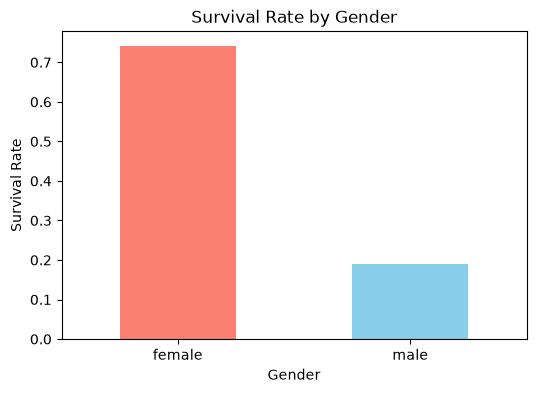

In [10]:
# Visualization 1: Survival count by gender

plt.figure(figsize=(6,4))
df_clean.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.show()

**Observation:** Female passengers had a survival rate of approximately 74%, 
while male passengers had a survival rate of approximately 19% — nearly 4x lower. 
This strongly reflects the historical "women and children first" evacuation 
priority during the Titanic disaster, where lifeboat access was prioritized 
by gender.

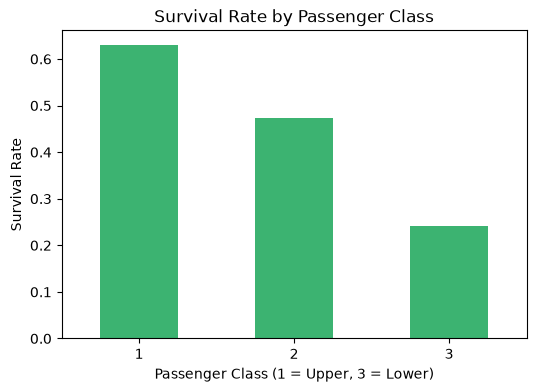

In [11]:
# Visualization 2: Survival rate by passenger class

plt.figure(figsize=(6,4))
df_clean.groupby('Pclass')['Survived'].mean().plot(kind='bar', color='mediumseagreen')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class (1 = Upper, 3 = Lower)')
plt.xticks(rotation=0)
plt.show()

**Observation:** Survival rate decreases consistently as passenger class 
decreases — 1st class passengers had roughly 63% survival, 2nd class 
around 47%, and 3rd class only 24%. This suggests that class (linked to 
cabin location, proximity to lifeboats, and possibly boarding priority) 
had a significant impact on survival chances, independent of gender.

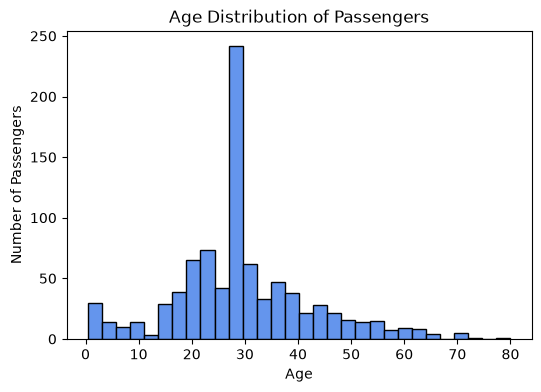

In [12]:
# Visualization 3: Age distribution of passengers

plt.figure(figsize=(6,4))
df_clean['Age'].plot(kind='hist', bins=30, color='cornflowerblue', edgecolor='black')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

**Observation:** The age distribution is mostly concentrated between 20-40 
years, with fewer children and elderly passengers. However, there is a 
noticeable artificial spike around age 28 — this is caused by our median 
imputation strategy, where all 177 missing ages were filled with the same 
median value. This is a known limitation of simple median-filling: it 
preserves the average but can distort the true shape of the distribution 
at that specific value.

## Summary of Findings

1. **Gender was the strongest predictor of survival** — females survived at 
   nearly 4x the rate of males (74% vs 19%), reflecting the "women and 
   children first" policy.
2. **Passenger class also strongly influenced survival** — 1st class 
   passengers survived at over 2.5x the rate of 3rd class passengers 
   (63% vs 24%), suggesting wealth/status affected access to lifeboats.
3. **Age had missing data (177 values, ~20% of dataset)**, which was handled 
   using median imputation — a reasonable but imperfect strategy that 
   introduced a visible artificial spike in the distribution.
4. **Cabin was dropped entirely** due to 77% missing data, as filling it 
   reliably was not feasible.